In [57]:
import yfinance as yf
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2020-01-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

# 로그 변화율 계산
returns["log_change"] = np.log(returns["Close"] / returns["Close"].shift(1))
returns = returns.dropna()

# 필요한 열만 선택
returns = returns[["log_change"]]

# 데이터 분할 기준일: 가장 최신 날짜 기준으로 일주일 전
split_date = returns.index[-7]

# 학습 데이터: 일주일 전까지
train_data = returns[returns.index < split_date]

# 검증 데이터: 일주일 동안
test_data = returns[returns.index >= split_date]

print(f"학습 데이터 기간: {train_data.index.min()} ~ {train_data.index.max()}")
print(f"검증 데이터 기간: {test_data.index.min()} ~ {test_data.index.max()}")


[*********************100%***********************]  1 of 1 completed

학습 데이터 기간: 2020-01-03 00:00:00 ~ 2025-04-29 00:00:00
검증 데이터 기간: 2025-04-30 00:00:00 ~ 2025-05-08 00:00:00


In [62]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az



def make_stochastic_volatility_model(train_data):
    with pm.Model() as model:
        # MutableData로 시계열 기간과 데이터 정의
        time_index = pm.MutableData("time_index", train_data.index.values)
        observed_data = pm.MutableData("observed_data", train_data["log_change"].values)

        # 데이터 길이 추출 (동적으로 변경 가능)
        data_length = observed_data.shape[0]

        # 로그 변동성 과정
        step_size = pm.Exponential("step_size", 10)
        log_volatility = pm.GaussianRandomWalk("log_volatility", sigma=step_size, shape=data_length)
        
        lam = pm.Deterministic("lambda", pm.math.exp(-2 * log_volatility))

        # 자유도
        nu = pm.Exponential("nu", 0.1)

        # 과거 시점의 관측 모델
        pm.StudentT(
            "returns", 
            nu=nu, 
            lam=lam, 
            observed=observed_data, 
            shape=data_length
        )

    return model

# 모델 생성
stochastic_vol_model = make_stochastic_volatility_model(train_data)

/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


In [63]:
rng = np.random.RandomState(1234)
az.style.use("arviz-darkgrid")

In [64]:
with stochastic_vol_model:
    idata = pm.sample_prior_predictive(500, random_seed=rng)

prior_predictive = idata.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [log_volatility, nu, returns, step_size]


In [65]:
idata

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data

In [68]:
idata.constant_data['time_index'].values.astype('datetime64[ns]')

array(['2020-01-03T00:00:00.000000000', '2020-01-06T00:00:00.000000000',
       '2020-01-07T00:00:00.000000000', ...,
       '2025-04-25T00:00:00.000000000', '2025-04-28T00:00:00.000000000',
       '2025-04-29T00:00:00.000000000'], dtype='datetime64[ns]')

In [69]:
prior_predictive

<xarray.Dataset>
Dimensions:        (returns_dim_0: 1337, pooled_chain: 500)
Coordinates:
  * returns_dim_0  (returns_dim_0) int64 0 1 2 3 4 ... 1332 1333 1334 1335 1336
  * pooled_chain   (pooled_chain) object MultiIndex
  * chain          (pooled_chain) int64 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
  * draw           (pooled_chain) int64 0 1 2 3 4 5 ... 494 495 496 497 498 499
Data variables:
    returns        (returns_dim_0, pooled_chain) float64 1.131e+13 ... 5.632e+15
Attributes:
    created_at:                 2025-05-09T05:23:52.499105
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

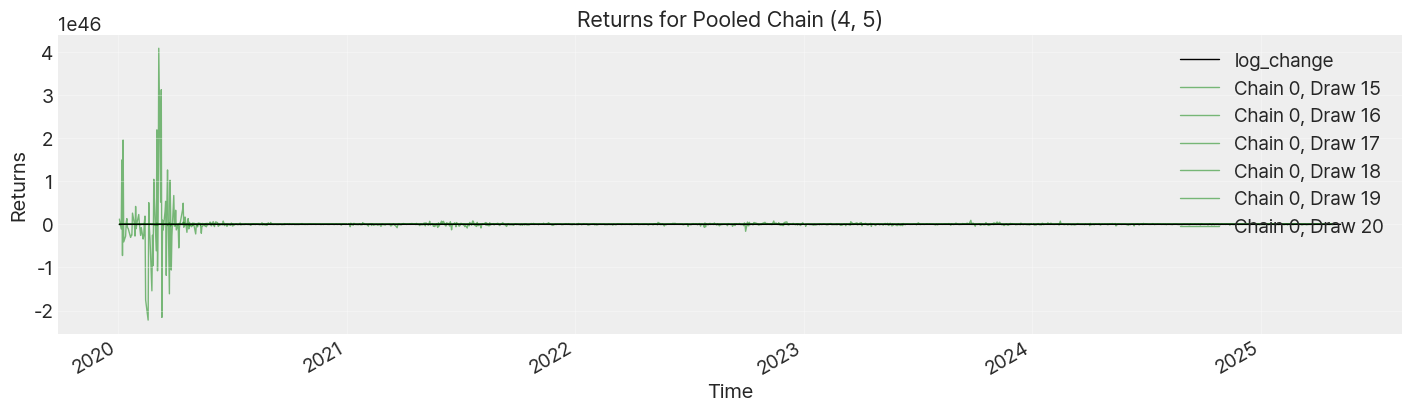

In [73]:

subset = prior_predictive["returns"].isel(pooled_chain=slice(15, 21, None))

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["log_change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    x_vals = idata.constant_data['time_index'].values.astype('datetime64[ns]')
    plt.plot(x_vals, subset[:, i], label=label, color="g",
    alpha=0.5,
    lw=1,
    zorder=-10,)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [76]:
with stochastic_vol_model:
    idata.extend(pm.sample(5000, target_accept=0.95, return_inferencedata=True, idata_kwargs={"log_likelihood": True}))



Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [step_size, log_volatility, nu]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 805 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [77]:
summary = az.summary(idata)
summary[summary["r_hat"] > 1.0].sort_values("r_hat", ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
step_size,0.095,0.011,0.073,0.116,0.001,0.0,298.0,656.0,1.01


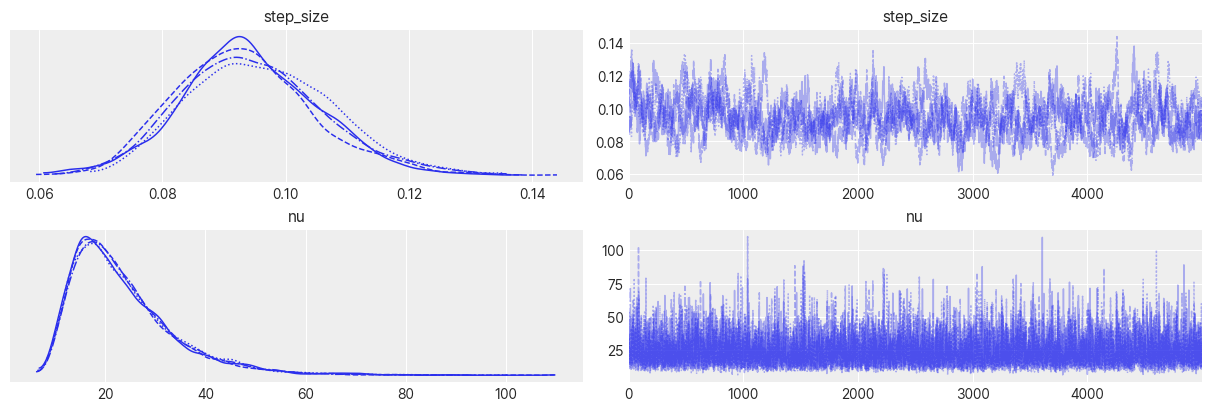

In [78]:
az.plot_trace(idata, var_names=["step_size", "nu"]);

In [79]:
from datetime import datetime
import arviz as az

# 현재 날짜와 시간
now = datetime.now()
formatted_time = now.strftime("%Y%m%d%H%M")  # 202505081200 형식

# 파일 저장
az.to_netcdf(idata, f"trace-{formatted_time}.nc")

'trace-202505090546.nc'

In [81]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

In [82]:
az.loo(idata)

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 20000 posterior samples and 1337 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  4222.58    33.23
p_loo       73.28        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     1323   99.0%
 (0.5, 0.7]   (ok)         13    1.0%
   (0.7, 1]   (bad)         1    0.1%
   (1, Inf)   (very bad)    0    0.0%

In [86]:
with stochastic_vol_model:
    forecast_returns = pm.sample_posterior_predictive(idata, predictions=True, var_names=["returns"])

Sampling: [returns]


In [85]:
forecast_returns

Inference data with groups:
	> posterior_predictive
	> observed_data
	> constant_data

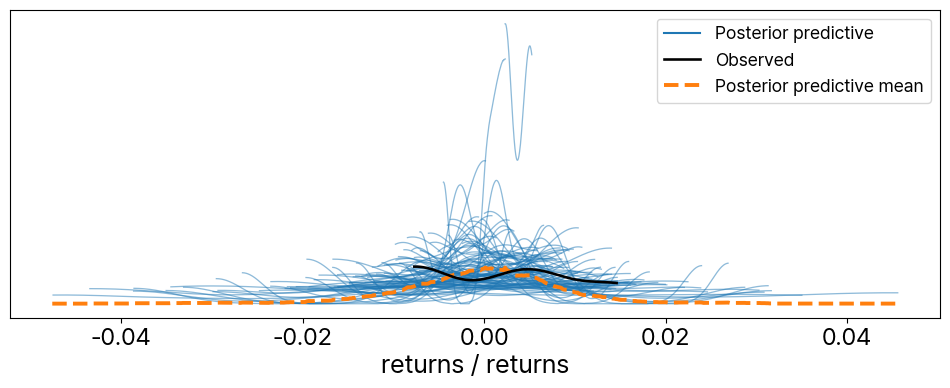

In [40]:
az.plot_ppc(forecast_returns, num_pp_samples=100, figsize=(12, 4), kind="kde", alpha=0.5);

In [30]:
# 검증 기간 설정
test_dates = test_data.index.values
test_observed = test_data["log_change"].values

# 검증 데이터로 업데이트
with stochastic_vol_model:
    pm.set_data({
        "time_index": test_dates,
        "observed_data": test_observed
    })

    # 검증 데이터 예측
    posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["returns"])


Sampling: [returns]


In [31]:
posterior_predictive

Inference data with groups:
	> posterior_predictive
	> observed_data
	> constant_data

In [35]:
az.loo(trace)

TypeError: log likelihood not found in inference data object

In [ ]:

# 예측값 추출
predicted_log_change = posterior_predictive["returns"].mean(axis=0)

# 결과 저장
test_data["predicted_log_change"] = predicted_log_change

print(test_data[["log_change", "predicted_log_change"]])
